<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Downloading...
From (original): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
From (redirected): https://drive.google.com/uc?id=1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO&confirm=t&uuid=cef6a8b4-924e-4103-92ea-944540b937e3
To: /content/sound_classification_dataset.zip
100% 645M/645M [00:04<00:00, 161MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
To: /content/train.csv
100% 3.09k/3.09k [00:00<00:00, 17.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1my0RPDQdTxvCGmnZei06tiXgKko3R4o4
To: /content/valid.csv
100% 1.06k/1.06k [00:00<00:00, 5.50MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks
To: /content/test.csv
100% 719/719 [00:00<00:00, 2.29MB/s]


Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
!unzip /content/sound_classification_dataset.zip

Archive:  /content/sound_classification_dataset.zip
   creating: content/sound_classification_dataset/
  inflating: content/sound_classification_dataset/1-61261-A-44.wav  
  inflating: content/sound_classification_dataset/2-104105-A-19.wav  
  inflating: content/sound_classification_dataset/3-150363-A-38.wav  
  inflating: content/sound_classification_dataset/1-18074-A-6.wav  
  inflating: content/sound_classification_dataset/5-161270-A-33.wav  
  inflating: content/sound_classification_dataset/5-221529-A-39.wav  
  inflating: content/sound_classification_dataset/2-61618-A-46.wav  
  inflating: content/sound_classification_dataset/1-46274-A-18.wav  
  inflating: content/sound_classification_dataset/1-69760-A-16.wav  
  inflating: content/sound_classification_dataset/2-64963-A-15.wav  
  inflating: content/sound_classification_dataset/2-108766-A-9.wav  
  inflating: content/sound_classification_dataset/4-165845-A-45.wav  
  inflating: content/sound_classification_dataset/5-235644-A-30.w

In [3]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [4]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [5]:
pip install torch torchaudio torch-audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 6.1 MB/s eta 0:00:00
  Created wheel for julius: filename=julius-0.2.7-py3-none-any.whl size=21870 sha256=87cfdec7e2bc79fa872422db894b5561f41bf054a61b1a4d5ce50699f39881e3
  Stored in directory: /root/.cache/pip/wheels/de/c1/ca/544dafe48401e8e2e17064dfe465a390fca9e8720ffa12e744
Successfully built julius


С аугментациями PitchShift и TimeStretch возникли проблемы, решил не использовать.
Отдельное задание классов понадобилось для Part 4

In [6]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
import torch_audiomentations as audiomentations

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, df, audio_dir, target_length=4, target_sample_rate=16000, do_augmentation=False):
        self.df = df
        self.audio_dir = audio_dir
        self.target_length = target_length
        self.target_sample_rate = target_sample_rate
        self.do_augmentation = do_augmentation
        #self._init_augmentations()
        # Число семплов
        self.target_samples = int(target_length * target_sample_rate)

        self.classes = ['sneezing','rain','crying_baby','clock_tick','dog']
        self.label_mapping = {
            'sneezing': 0,
            'rain': 1,
            'crying_baby': 2,
            'clock_tick': 3,
            'dog': 4
        }

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):
        # 1. Get the file path and label
        filename = self.df.iloc[index]['filename']
        audio_file_path = os.path.join(self.audio_dir, filename)

        label = self._extract_label(index)

        # 2. LOAD: Load the raw audio file
        signal, sample_rate = torchaudio.load(audio_file_path)

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        #signal=(signal-signal.mean())/(signal.std()+ 1e-8)

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        signal = signal.squeeze()#1

        # 5. RETURN: We now have a clean, standardized waveform and its label
        return signal, label

    def _extract_label(self, index):
        text_label = self.df.iloc[index, 1]

        # Mapping текстовых меток в числовые
        label_mapping = {
            'sneezing': 0,
            'rain': 1,
            'crying_baby': 2,
            'clock_tick': 3,
            'dog': 4
        }

    # Конвертируем текстовую метку в числовую
        return label_mapping.get(text_label, 0)

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=self.target_sample_rate)
            signal = resampler(signal)

        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:  # If multi-channel
            signal = torch.mean(signal, dim=0, keepdim=True)

        return signal

    def _cut_or_pad(self, signal):
        current_length = signal.shape[1]

        if current_length > self.target_samples:
            start = (current_length - self.target_samples) // 2
            signal = signal[:, start:start + self.target_samples]
        elif current_length < self.target_samples:
            pad_length = self.target_samples - current_length
            padding = torch.zeros(1, pad_length)
            signal = torch.cat([signal, padding], dim=1)

        return signal

    def _augmentation(self, signal):
        # Initialize and apply augmentations in one method
        augmentation_transforms = audiomentations.Compose([
            audiomentations.Gain(min_gain_in_db=-6, max_gain_in_db=6, p=0.5),
            #audiomentations.PitchShift(min_semitones=-2.0, max_semitones=2.0, p=0.3),
            audiomentations.AddColoredNoise(min_snr_in_db=10, max_snr_in_db=30, p=0.3),
            #audiomentations.TimeStretch(min_rate=0.8, max_rate=1.2, p=0.3),
            audiomentations.Shift(min_shift=-0.5, max_shift=0.5, p=0.3),
        ])

        signal = signal.unsqueeze(0)  # Add batch dimension
        augmented_signal = augmentation_transforms(signal, sample_rate=self.target_sample_rate)
        return augmented_signal.squeeze(0)  # Remove batch dimension

In [7]:
audio_dir = "/content/content/sound_classification_dataset"

# Создание датасетов
train_dataset = SimpleAudioDataset(
    df=train_df,
    audio_dir=audio_dir,
    target_length=4,
    target_sample_rate=16000,
    do_augmentation=True
)

valid_dataset = SimpleAudioDataset(
    df=valid_df,
    audio_dir=audio_dir,
    target_length=4,
    target_sample_rate=16000,
    do_augmentation=False
)

test_dataset = SimpleAudioDataset(
    df=test_df,
    audio_dir=audio_dir,
    target_length=4,
    target_sample_rate=16000,
    do_augmentation=False
)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

Использую простую модель

In [8]:
import torch.nn as nn

class SoundClassificatonModel(nn.Module):


    def __init__(self, input_size=16000*4, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=64, stride=2, padding=32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(8, 8),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=32, stride=2, padding=16),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(8, 8),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=16, stride=2, padding=8),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),

            # Block 4
            nn.Conv1d(128, 256, kernel_size=8, stride=2, padding=4),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, input_size)
        x = self.features(x)
        x = x.squeeze(-1)
        x = self.classifier(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [9]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


Epoch 50/50:
  Train Loss: 0.2692, Train Acc: 0.8880
  Valid Loss: 0.2129, Valid Acc: 0.9688
  Learning Rate: 0.000250


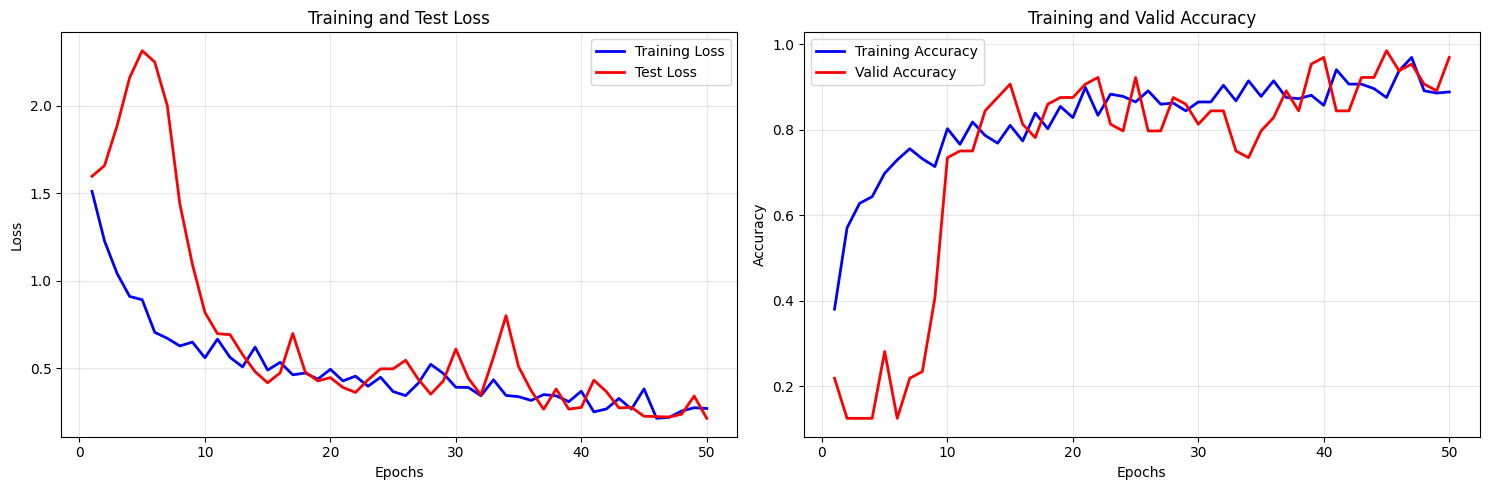

In [10]:
from torch.utils.data import DataLoader
from IPython.display import clear_output


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(train_df, audio_dir, target_length=4, target_sample_rate=16000, do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df, audio_dir, target_length=4, target_sample_rate=16000, do_augmentation=False)
test_data = SimpleAudioDataset(test_df, audio_dir, target_length=4, target_sample_rate=16000, do_augmentation=False)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel().to(device)
#model = SoundClassificatonModel_New().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 50
for epoch in range(n_epochs):

    train_epoch_loss = 0.0
    train_epoch_acc = 0.0
    train_batches = 0

    valid_epoch_loss = 0.0
    valid_epoch_acc = 0.0
    valid_batches = 0

    # Train
    model.train()

    def calculate_accuracy(predictions, labels):
        _, predicted = torch.max(predictions, 1)
        correct = (predicted == labels).float()
        return correct.mean()

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        train_accuracy = calculate_accuracy(predictions, labels)

        # Backward pass
        train_loss.backward()
        optimizer.step()

        train_epoch_loss += train_loss.item()
        train_epoch_acc += train_accuracy.item()
        train_batches += 1

    # Evaluation
    model.eval()
    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            valid_accuracy = calculate_accuracy(predictions, labels)

            valid_epoch_loss += valid_loss.item()
            valid_epoch_acc += valid_accuracy.item()
            valid_batches += 1

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = train_epoch_loss / train_batches
    epoch_train_acc = train_epoch_acc / train_batches

    epoch_valid_loss = valid_epoch_loss / valid_batches
    epoch_valid_acc = valid_epoch_acc / valid_batches

    scheduler.step(epoch_valid_loss)

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

   # Print progress
    print(f'Epoch {epoch+1}/{n_epochs}:')
    print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}')
    print(f'  Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}')
    print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')


    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

Лучшая точность и точность на последней эпохе обучения

In [11]:
print("Train Accuracy = ", max(train_accuracies))
print("Valid Accuracy = ", max(valid_accuracies))
# Точность на последней эпохе:
print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}')
print(f'  Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}')

Train Accuracy =  0.96875
Valid Accuracy =  0.984375
  Train Loss: 0.2692, Train Acc: 0.8880
  Valid Loss: 0.2129, Valid Acc: 0.9688


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


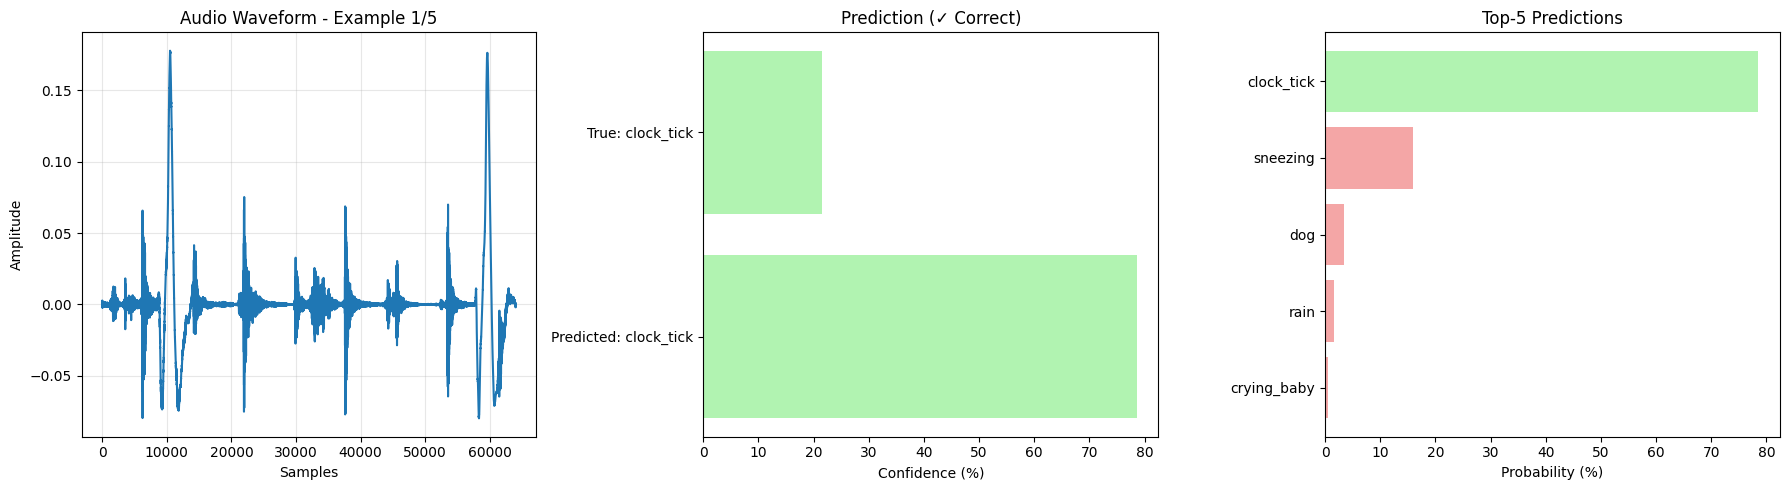

Playing: clock_tick


Prediction: clock_tick (78.54%)
True label: clock_tick
Correct: True


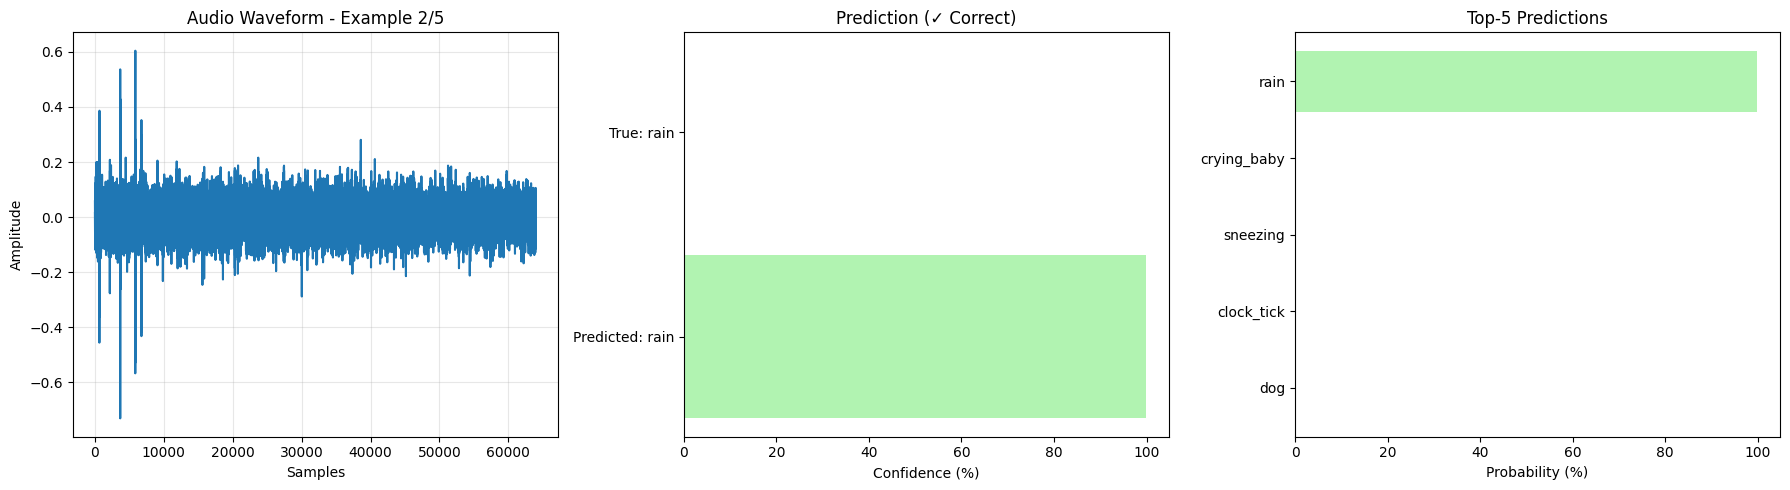

Playing: rain


Prediction: rain (99.86%)
True label: rain
Correct: True


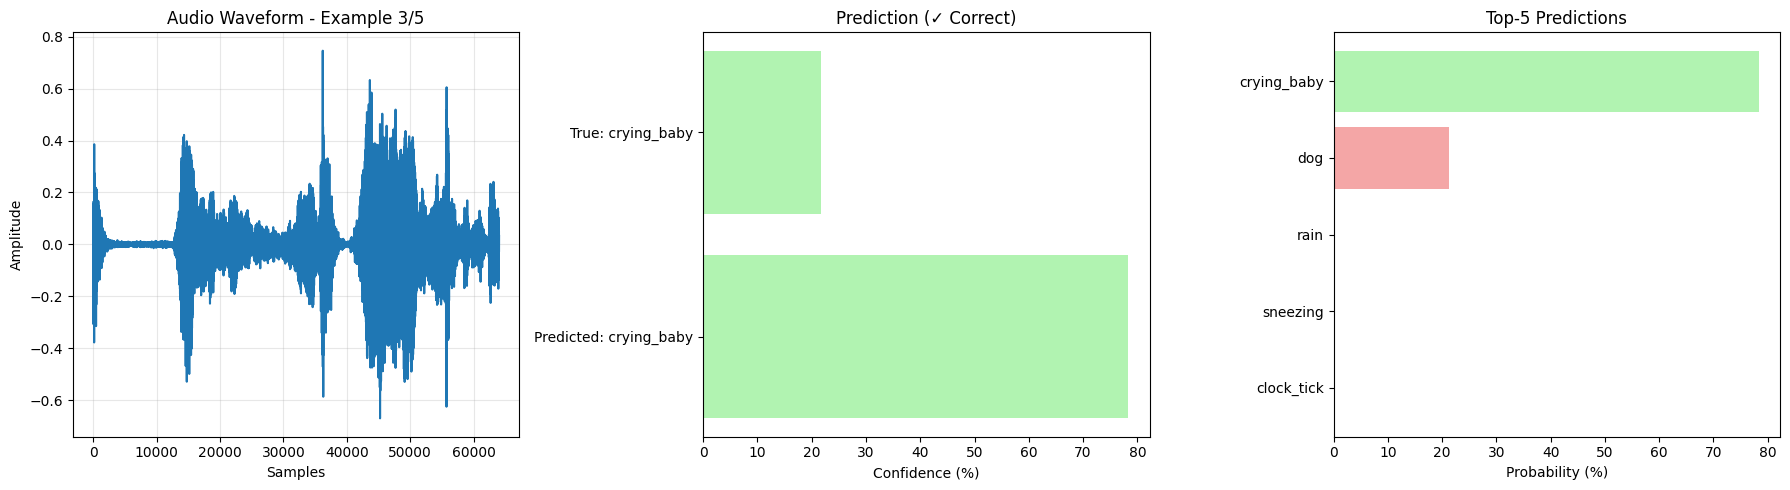

Playing: crying_baby


Prediction: crying_baby (78.36%)
True label: crying_baby
Correct: True


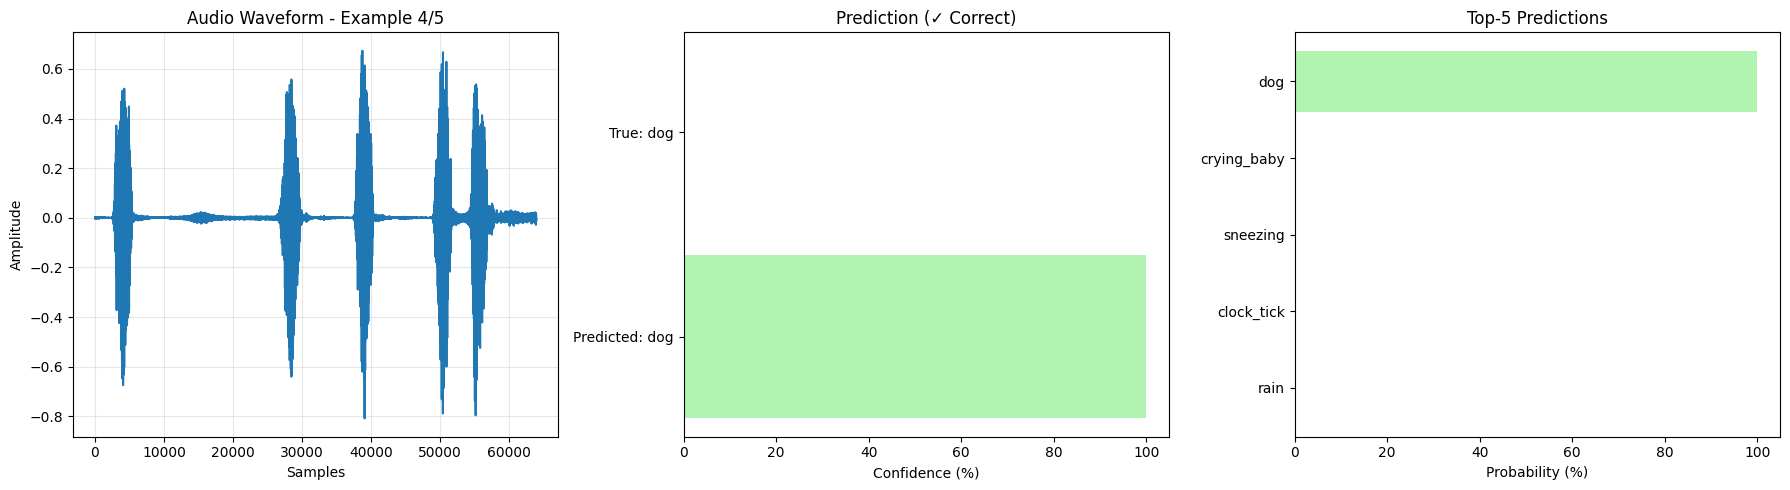

Playing: dog


Prediction: dog (99.94%)
True label: dog
Correct: True


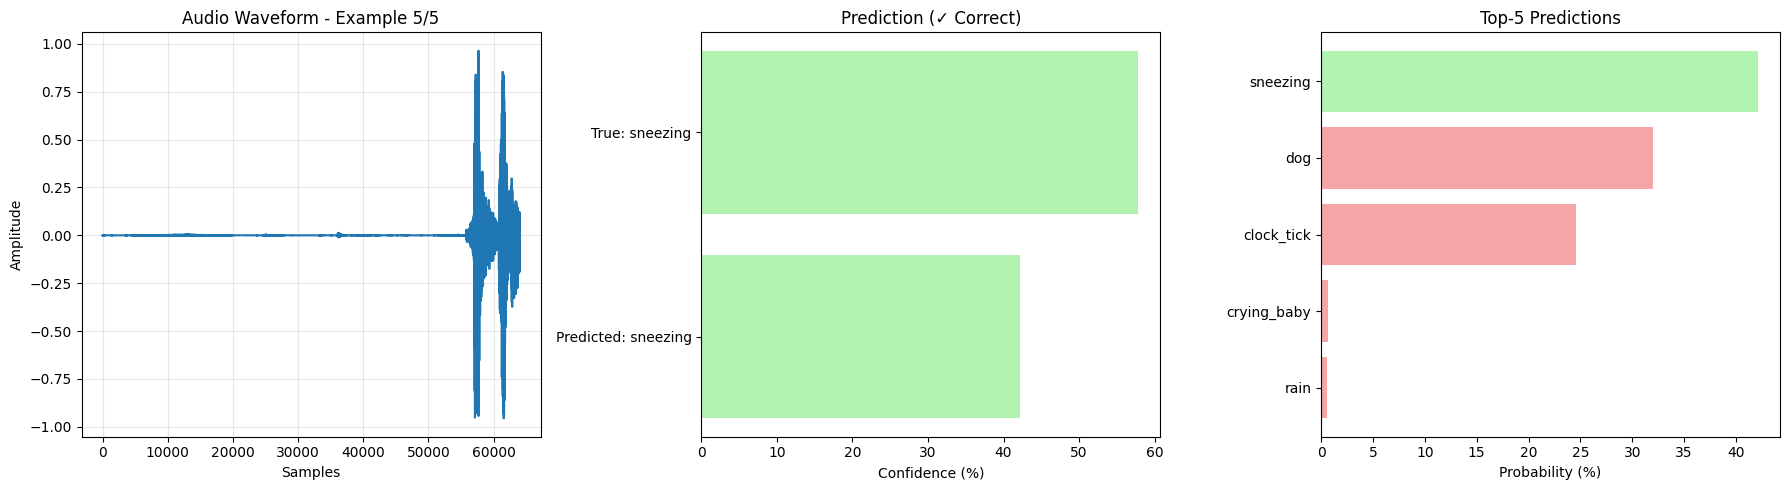

Playing: sneezing


Prediction: sneezing (42.14%)
True label: sneezing
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 38/40
Accuracy: 95.00%


In [12]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = self._get_classes_from_dataset(test_dataset)
        self.model.eval()  # Set to evaluation mode

    def _get_classes_from_dataset(self, dataset):
        """Извлекает или создает список классов из датасета"""
        if hasattr(dataset, 'classes'):
            return dataset.classes
        elif hasattr(dataset, 'label_mapping'):
            # Создаем список классов из label_mapping
            label_mapping = dataset.label_mapping
            # Инвертируем mapping: {0: 'sneezing', 1: 'rain', ...}
            inverted_mapping = {v: k for k, v in label_mapping.items()}
            # Создаем список в правильном порядке
            classes = [inverted_mapping[i] for i in range(len(inverted_mapping))]
            return classes
        else:
            # Fallback: используем стандартные названия классов
            return ['sneezing', 'rain', 'crying_baby', 'clock_tick', 'dog']

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [13]:
# Создаем исправленный датасет для test.csv
class TestAudioDataset(Dataset):
    def __init__(self, df, audio_dir, target_length=4, target_sample_rate=16000):
        self.df = df
        self.audio_dir = audio_dir
        self.target_length = target_length
        self.target_sample_rate = target_sample_rate
        self.target_samples = int(target_length * target_sample_rate)

        # Пропускаем заголовок - начинаем с первой строки данных
        self.filenames = df['filename'].tolist()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        filename = self.filenames[index]
        audio_file_path = os.path.join(self.audio_dir, filename)

        # Загрузка аудио
        try:
            signal, sample_rate = torchaudio.load(audio_file_path)
        except Exception as e:
            print(f"Error loading {audio_file_path}: {e}")
            signal = torch.zeros(1, self.target_samples)
            sample_rate = self.target_sample_rate

        # Предобработка
        signal = self._resample(signal, sample_rate)
        signal = self._stereo_to_mono(signal)
        signal = self._cut_or_pad(signal)
        #signal = (signal - signal.mean()) / (signal.std() + 1e-8)

        return signal.squeeze()

    def _resample(self, signal, original_sr):
        if original_sr != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=self.target_sample_rate)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        current_length = signal.shape[1]
        if current_length > self.target_samples:
            start = (current_length - self.target_samples) // 2
            signal = signal[:, start:start + self.target_samples]
        elif current_length < self.target_samples:
            pad_length = self.target_samples - current_length
            padding = torch.zeros(1, pad_length, dtype=signal.dtype)
            signal = torch.cat([signal, padding], dim=1)
        return signal

# Создаем исправленный test dataset
test_dataset_corrected = TestAudioDataset(
    df=test_df,
    audio_dir=audio_dir,
    target_length=4,
    target_sample_rate=16000
)

test_loader_corrected = DataLoader(test_dataset_corrected, batch_size=32, shuffle=False)

# Теперь получаем предсказания
model.eval()
y_test_pred = []

with torch.no_grad():
    for signals in test_loader_corrected:
        signals = signals.to(device)
        outputs = model(signals)
        _, predicted = torch.max(outputs, 1)
        y_test_pred.extend(predicted.cpu().numpy())

y_test_pred = np.array(y_test_pred)

In [14]:
class_names = ['sneezing','rain','crying_baby','clock_tick','dog']
y_test_pred = np.array([class_names[pred] for pred in y_test_pred])

In [15]:
submission = pd.read_csv("/content/test.csv")
submission['category'] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

In [16]:
from google.colab import files
files.download("/content/submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

*Делал по материалам  лекции и описанию домашней работы*.
*Модель была примерно , как изначльно в шаблоне , почти без изменений*